# STEP 4.1.4: ARIMAX

Mục tiêu: xây dựng mô hình ARIMAX để dự báo `cpi_mom`.

Nội dung:
- Kiểm tra tính dừng.
- Biến đổi biến ngoại sinh.
- Tối ưu tham số ARIMAX.
- Đánh giá mô hình trên tập test.
- Kiểm định phần dư.
- Chỉ vẽ dự báo tương lai nếu mô hình đạt benchmark.

## 1. Thiết lập

In [80]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

DATA_DIR = os.path.join(os.getcwd(), "data", "processed")
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step4_arimax")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Data:", DATA_DIR)
print("Output:", OUTPUT_DIR)

Data: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed
Output: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step4_arimax


## 2. Load dữ liệu

In [81]:
cleaned_data = pd.read_csv(os.path.join(DATA_DIR, "cpi_02_06_selected_variables.csv"))
cleaned_data["date"] = pd.to_datetime(cleaned_data["date"])
cleaned_data = cleaned_data.sort_values("date").reset_index(drop=True)

print("Số dòng, số cột:", cleaned_data.shape)
print("Thời gian:", cleaned_data["date"].min().date(), "đến", cleaned_data["date"].max().date())
print("Missing:", cleaned_data.isnull().sum().sum())

Số dòng, số cột: (360, 13)
Thời gian: 1995-01-01 đến 2024-12-01
Missing: 0


## 3. Chọn biến mục tiêu và biến ngoại sinh

In [82]:
target_var = "cpi_mom"

candidate_exog_vars = ['cpi_mom', 'policy_rate', 'broad_money', 'ppi_qoq', 'wti', 'gasoline_world', 'gold', 
                 'policy_rate', 'VNINDEX', 'NIKKEI225', 'USDVND','gdp']

candidate_exog_vars = [v for v in candidate_exog_vars if v in cleaned_data.columns]

if target_var not in cleaned_data.columns:
    raise ValueError(f"Không tìm thấy biến mục tiêu: {target_var}")

df = cleaned_data[["date", target_var] + candidate_exog_vars].copy()
df = df.dropna().sort_values("date").set_index("date")
df = df.asfreq("MS").ffill().bfill()

print("Target:", target_var)
print("Số biến ngoại sinh:", len(candidate_exog_vars))
print("Shape:", df.shape)

Target: cpi_mom
Số biến ngoại sinh: 12
Shape: (360, 13)


## 4. Kiểm định tính dừng của target

In [83]:
def adf_pvalue(series):
    try:
        s = pd.Series(series).dropna()
        if len(s) < 4:
            return np.nan
        result = adfuller(s, autolag="AIC", regression="c")
        return result[1]
    except Exception as e:
        print(f"ADF error: {e}")
        return np.nan


def kpss_pvalue(series):
    try:
        s = pd.Series(series).dropna()
        if len(s) < 4:
            return np.nan
        result = kpss(s, regression="c", nlags="auto")
        return result[1]
    except Exception as e:
        print(f"KPSS error: {e}")
        return np.nan


y = df[target_var].astype(float)
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]
y = y.squeeze()
print("Target series info:")
print(f"  Length: {len(y)}, Non-null: {y.notna().sum()}")
print(f"  Sample values:\n{y.head()}")

adf_p = adf_pvalue(y)
kpss_p = kpss_pvalue(y)

suggested_d = 0 if (adf_p is not None and adf_p < 0.05 and kpss_p is not None and kpss_p > 0.05) else 1

print("ADF p-value:", round(adf_p, 6) if adf_p is not None else "N/A")
print("KPSS p-value:", round(kpss_p, 6) if kpss_p is not None else "N/A")
print("d đề xuất:", suggested_d)

Target series info:
  Length: 360, Non-null: 360
  Sample values:
date
1995-01-01    103.8
1995-02-01    103.4
1995-03-01    100.2
1995-04-01    101.0
1995-05-01    101.8
Freq: MS, Name: cpi_mom, dtype: float64
ADF p-value: 0.003148
KPSS p-value: 0.1
d đề xuất: 0


## 5. Phân tích mùa vụ

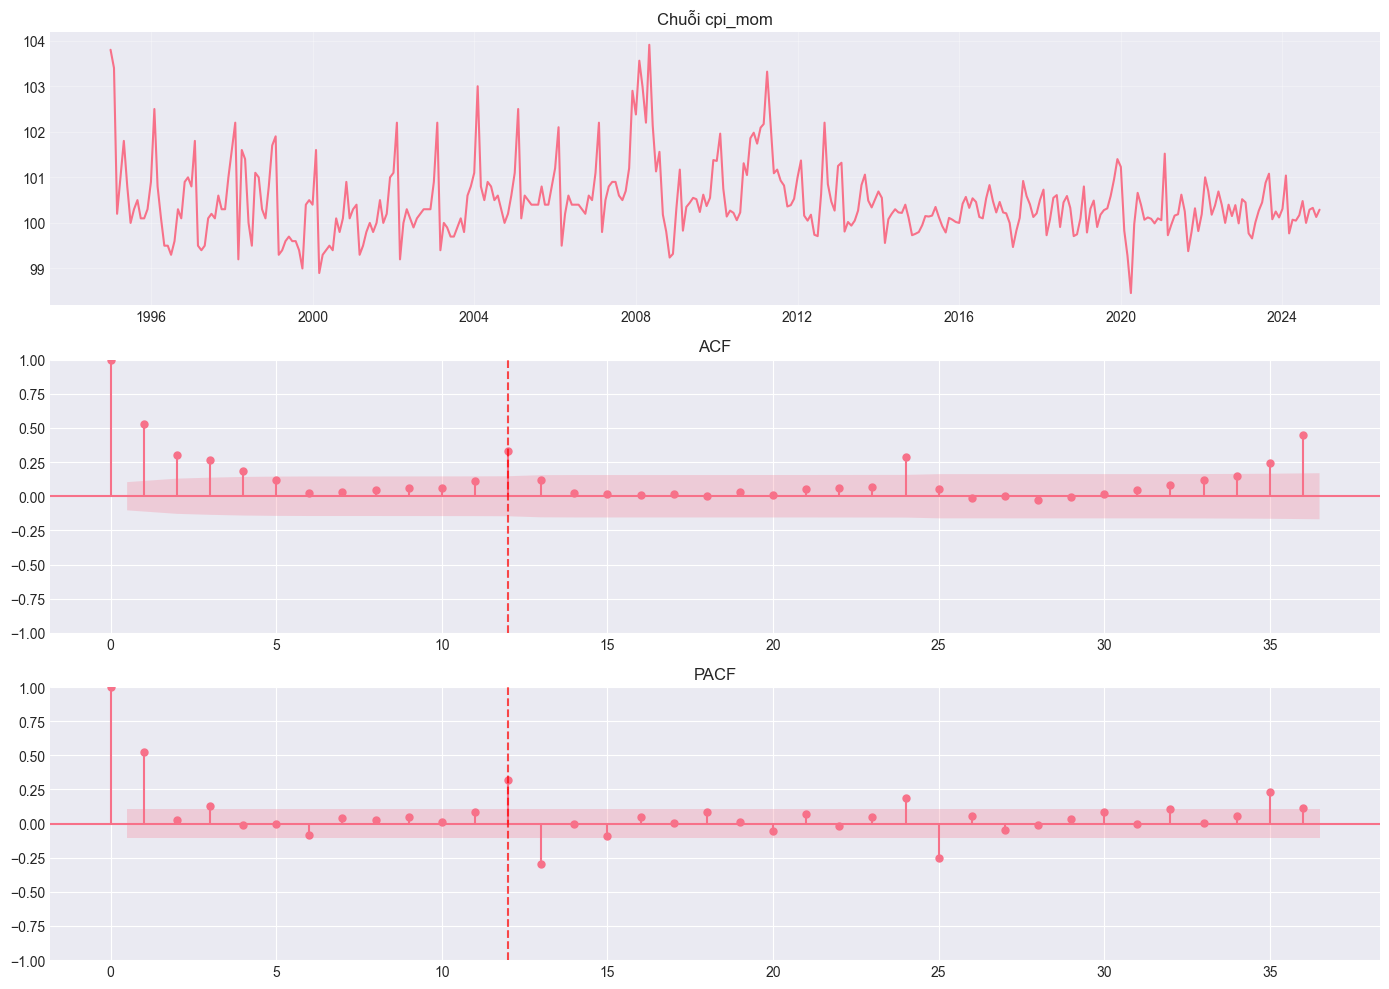

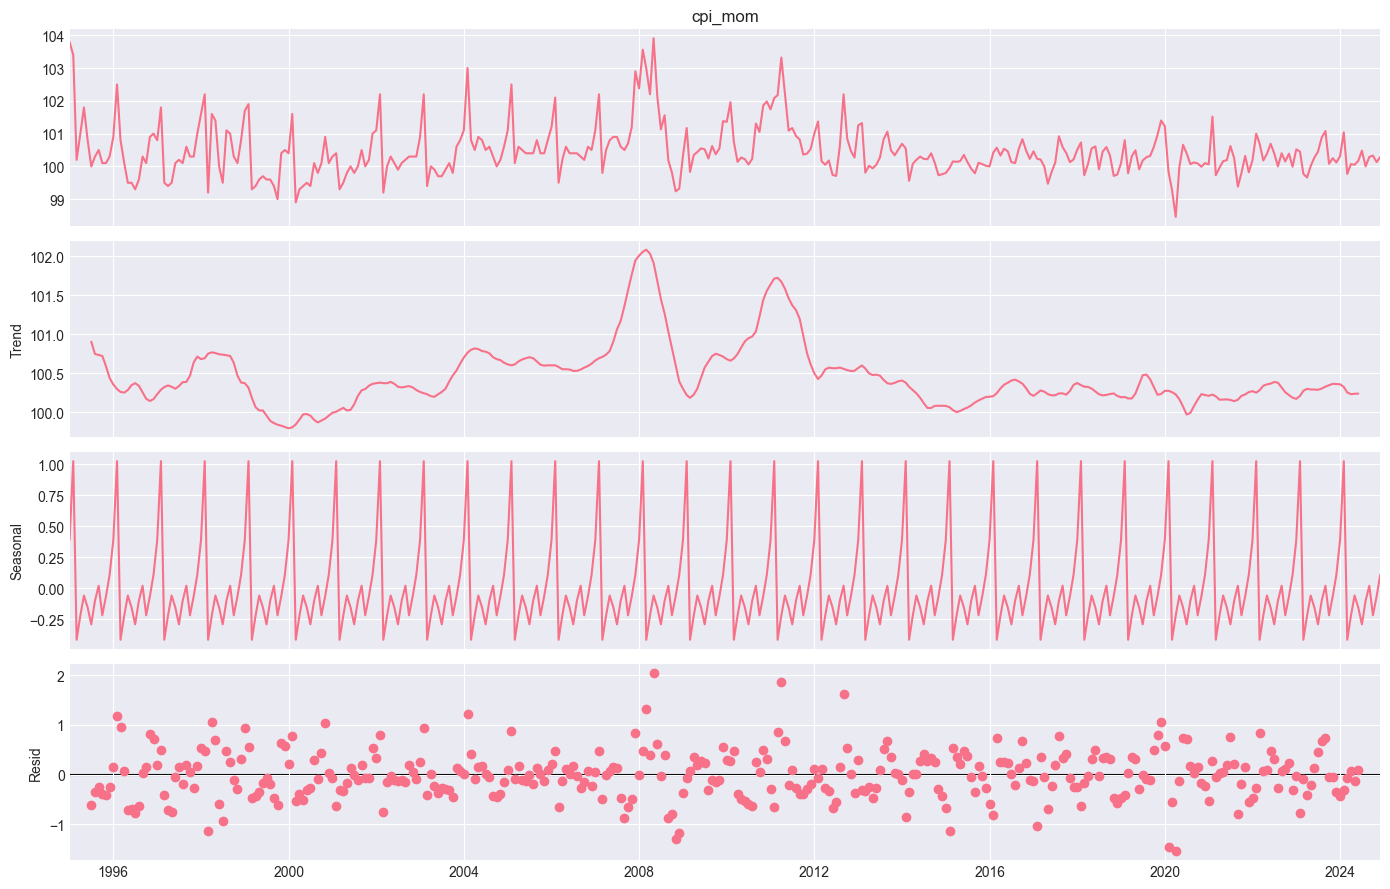

Trend strength: 0.414
Seasonal strength: 0.3601


In [84]:
seasonal_period = 12

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(y.index, y.values)
axes[0].set_title(f"Chuỗi {target_var}")
axes[0].grid(True, alpha=0.3)

plot_acf(y, lags=min(36, len(y)//2), ax=axes[1])
axes[1].axvline(seasonal_period, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("ACF")

plot_pacf(y, lags=min(36, len(y)//2 - 1), ax=axes[2], method="ywm")
axes[2].axvline(seasonal_period, color="red", linestyle="--", alpha=0.7)
axes[2].set_title("PACF")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "target_acf_pacf.png"), dpi=150)
plt.show()

try:
    dec = seasonal_decompose(y, model="additive", period=seasonal_period)
    fig = dec.plot()
    fig.set_size_inches(14, 9)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "seasonal_decompose.png"), dpi=150)
    plt.show()

    trend_strength = dec.trend.var() / (dec.trend.var() + dec.resid.var())
    seasonal_strength = dec.seasonal.var() / (dec.seasonal.var() + dec.resid.var())
    print("Trend strength:", round(trend_strength, 4))
    print("Seasonal strength:", round(seasonal_strength, 4))
except Exception as e:
    seasonal_strength = 0
    print("Không phân rã mùa vụ được:", e)

## 6. Biến đổi biến ngoại sinh

In [85]:
def classify_stationarity(series):
    a = adf_pvalue(series)
    k = kpss_pvalue(series)
    if pd.notna(a) and pd.notna(k) and a < 0.05 and k > 0.05:
        return "I(0)", a, k
    if pd.notna(a) and a > 0.05:
        return "Non-stationary", a, k
    return "Mixed", a, k


df_model = pd.DataFrame(index=df.index)
target_series = df[target_var].astype(float)
if isinstance(target_series, pd.DataFrame):
    target_series = target_series.iloc[:, 0]
df_model[target_var] = target_series.squeeze()

rows = []
exog_transformed_cols = []

for col in candidate_exog_vars:
    s = df[col].astype(float)
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]
    s = s.squeeze()

    if col.startswith("shock_") or col in ["month", "quarter"]:
        new_col = col
        df_model[new_col] = s
        method = "level"
        status, a0, k0, a1, k1 = "calendar/dummy", np.nan, np.nan, np.nan, np.nan
    else:
        status, a0, k0 = classify_stationarity(s)
        if status == "I(0)":
            new_col = col
            df_model[new_col] = s
            method = "level"
            a1, k1 = a0, k0
        else:
            if (s > 0).all():
                new_col = f"dlog_{col}"
                df_model[new_col] = np.log(s).diff()
                method = "log_diff"
            else:
                new_col = f"diff_{col}"
                df_model[new_col] = s.diff()
                method = "diff"
            a1, k1 = adf_pvalue(df_model[new_col]), kpss_pvalue(df_model[new_col])

    exog_transformed_cols.append(new_col)
    rows.append({"gốc": col, "biến_đổi": new_col, "cách_làm": method, "trạng_thái": status, "ADF_sau": a1, "KPSS_sau": k1})

transform_df = pd.DataFrame(rows)
df_model = df_model.dropna()

print(transform_df.to_string(index=False))
print("Shape sau biến đổi:", df_model.shape)

           gốc            biến_đổi cách_làm     trạng_thái      ADF_sau  KPSS_sau
       cpi_mom             cpi_mom    level           I(0) 3.147732e-03       0.1
   policy_rate    dlog_policy_rate log_diff Non-stationary 1.100161e-12       0.1
   broad_money    dlog_broad_money log_diff Non-stationary 2.078913e-04       0.1
       ppi_qoq        diff_ppi_qoq     diff Non-stationary 1.350403e-14       0.1
           wti            dlog_wti log_diff Non-stationary 1.462145e-18       0.1
gasoline_world dlog_gasoline_world log_diff Non-stationary 2.053168e-08       0.1
          gold           dlog_gold log_diff Non-stationary 0.000000e+00       0.1
   policy_rate    dlog_policy_rate log_diff Non-stationary 1.100161e-12       0.1
       VNINDEX        dlog_VNINDEX log_diff Non-stationary 2.676718e-12       0.1
     NIKKEI225      dlog_NIKKEI225 log_diff Non-stationary 5.167798e-30       0.1
        USDVND         dlog_USDVND log_diff Non-stationary 1.861147e-03       0.1
           gdp  

## 7. Chọn biến ngoại sinh

In [86]:
# Lấy các biến ngoại sinh đã biến đổi (loại target_var)
exog_vars = [col for col in exog_transformed_cols if col != target_var]

print("Biến ngoại sinh được sử dụng:")
print(exog_vars)
print(f"Tổng: {len(exog_vars)} biến")

Biến ngoại sinh được sử dụng:
['dlog_policy_rate', 'dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gasoline_world', 'dlog_gold', 'dlog_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND', 'dlog_gdp']
Tổng: 11 biến


Biến ngoại sinh được lựa chọn từ các biến đã biến đổi để đảm bảo tính dừng. Tất cả các biến ngoại sinh đã biến đổi được sử dụng trong mô hình ARIMAX.

## 8. Chia train/test

In [87]:
test_ratio = 0.2
train_size = int(len(df_model) * (1 - test_ratio))

y_all = df_model[target_var]
y_train = y_all.iloc[:train_size]
y_test = y_all.iloc[train_size:]

print("Train:", len(y_train), y_train.index.min().date(), "đến", y_train.index.max().date())
print("Test:", len(y_test), y_test.index.min().date(), "đến", y_test.index.max().date())

Train: 287 1995-02-01 đến 2018-12-01
Test: 72 2019-01-01 đến 2024-12-01


## 9. Tối ưu ARIMAX

In [88]:
p_values = [0, 1, 2]
d_values = [suggested_d]
q_values = [0, 1, 2]

def fit_model(y_train, exog_train, order):
    try:
        model = ARIMA(y_train, exog=exog_train, order=order)
        res = model.fit()
        return res
    except Exception:
        return None

results = []
fitted_models = {}

exog_train = None if len(exog_vars) == 0 else df_model[exog_vars].iloc[:train_size]

for p in p_values:
    for d in d_values:
        for q in q_values:
            order = (p, d, q)
            res = fit_model(y_train, exog_train, order)
            if res is None:
                continue
            key = f"ARIMAX_{order}"
            fitted_models[key] = res
            results.append({
                "order": order,
                "AIC": res.aic,
                "BIC": res.bic,
                "key": key
            })

grid_results_df = pd.DataFrame(results)
print("Số mô hình hội tụ:", len(grid_results_df))
print(grid_results_df.sort_values("AIC").head(10).to_string(index=False))

Số mô hình hội tụ: 9
    order        AIC        BIC              key
(1, 0, 1) 614.984299 669.876533 ARIMAX_(1, 0, 1)
(1, 0, 2) 616.865702 675.417417 ARIMAX_(1, 0, 2)
(2, 0, 0) 617.200309 672.092543 ARIMAX_(2, 0, 0)
(2, 0, 1) 617.927949 676.479664 ARIMAX_(2, 0, 1)
(2, 0, 2) 619.087927 681.299125 ARIMAX_(2, 0, 2)
(1, 0, 0) 619.089156 670.321907 ARIMAX_(1, 0, 0)
(0, 0, 2) 629.311957 684.204190 ARIMAX_(0, 0, 2)
(0, 0, 1) 634.406663 685.639414 ARIMAX_(0, 0, 1)
(0, 0, 0) 669.692997 717.266265 ARIMAX_(0, 0, 0)


## 10. Đánh giá mô hình

In [89]:
def metrics(actual, pred):
    actual = np.asarray(actual)
    pred = np.asarray(pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    ss_res = np.sum((actual - pred) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return rmse, mae, mape, r2


def evaluate_row(row):
    res = fitted_models[row["key"]]
    exog_test = None if len(exog_vars) == 0 else df_model[exog_vars].iloc[train_size:]

    pred = res.get_forecast(steps=len(y_test), exog=exog_test)
    mean = pred.predicted_mean
    ci = pred.conf_int(alpha=0.05)

    rmse, mae, mape, r2 = metrics(y_test.values, mean.values)

    rw_pred = np.repeat(y_train.iloc[-1], len(y_test))
    mean_pred = np.repeat(y_train.mean(), len(y_test))
    rmse_rw, _, _, _ = metrics(y_test.values, rw_pred)
    rmse_mean, _, _, _ = metrics(y_test.values, mean_pred)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2,
        "RMSE_RW": rmse_rw,
        "Model_vs_RW": rmse / rmse_rw if rmse_rw > 0 else np.nan,
        "RMSE_Mean": rmse_mean,
        "Model_vs_Mean": rmse / rmse_mean if rmse_mean > 0 else np.nan,
        "pred_mean": mean,
        "pred_ci": ci
    }

eval_rows = []
eval_objects = {}

for _, row in grid_results_df.iterrows():
    try:
        out = evaluate_row(row)
        item = row.to_dict()
        item.update({k: v for k, v in out.items() if k not in ["pred_mean", "pred_ci"]})
        eval_rows.append(item)
        eval_objects[row["key"]] = out
    except Exception:
        pass

model_eval_df = pd.DataFrame(eval_rows).sort_values("RMSE")

cols = ["order", "AIC", "BIC", "RMSE", "MAE", "MAPE", "R2", "RMSE_RW", "Model_vs_RW", "RMSE_Mean", "Model_vs_Mean", "key"]
print(model_eval_df[cols].head(15).to_string(index=False))

    order        AIC        BIC     RMSE      MAE     MAPE        R2  RMSE_RW  Model_vs_RW  RMSE_Mean  Model_vs_Mean              key
(2, 0, 1) 617.927949 676.479664 0.489174 0.381264 0.380755 -0.085680 0.686673     0.712383   0.536969       0.910992 ARIMAX_(2, 0, 1)
(1, 0, 2) 616.865702 675.417417 0.514739 0.405673 0.405329 -0.202123 0.686673     0.749614   0.536969       0.958601 ARIMAX_(1, 0, 2)
(2, 0, 2) 619.087927 681.299125 0.515161 0.405806 0.405462 -0.204094 0.686673     0.750228   0.536969       0.959387 ARIMAX_(2, 0, 2)
(1, 0, 1) 614.984299 669.876533 0.518257 0.408291 0.407951 -0.218610 0.686673     0.754737   0.536969       0.965153 ARIMAX_(1, 0, 1)
(2, 0, 0) 617.200309 672.092543 0.520349 0.410175 0.409845 -0.228467 0.686673     0.757783   0.536969       0.969048 ARIMAX_(2, 0, 0)
(0, 0, 1) 634.406663 685.639414 0.523273 0.412222 0.411895 -0.242315 0.686673     0.762042   0.536969       0.974495 ARIMAX_(0, 0, 1)
(1, 0, 0) 619.089156 670.321907 0.523859 0.414563 0.414244 -0.

## 11. Mô hình tốt nhất

In [90]:
best_row = model_eval_df.iloc[0]
best_key = best_row["key"]
best_model = fitted_models[best_key]
best_eval = eval_objects[best_key]

print("Mô hình tốt nhất:", best_key)
print("Order:", best_row["order"])
print("RMSE:", round(best_row["RMSE"], 6))
print("MAE:", round(best_row["MAE"], 6))
print("R2:", round(best_row["R2"], 4))
print("Model_vs_RW:", round(best_row["Model_vs_RW"], 4))
print(best_model.summary())

Mô hình tốt nhất: ARIMAX_(2, 0, 1)
Order: (2, 0, 1)
RMSE: 0.489174
MAE: 0.381264
R2: -0.0857
Model_vs_RW: 0.7124
                               SARIMAX Results                                
Dep. Variable:                cpi_mom   No. Observations:                  287
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -292.964
Date:                Tue, 02 Jun 2026   AIC                            617.928
Time:                        20:48:53   BIC                            676.480
Sample:                    02-01-1995   HQIC                           641.395
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 100.5195      0.190    529.783      0.000     100.148    

## 12. Actual vs Forecast

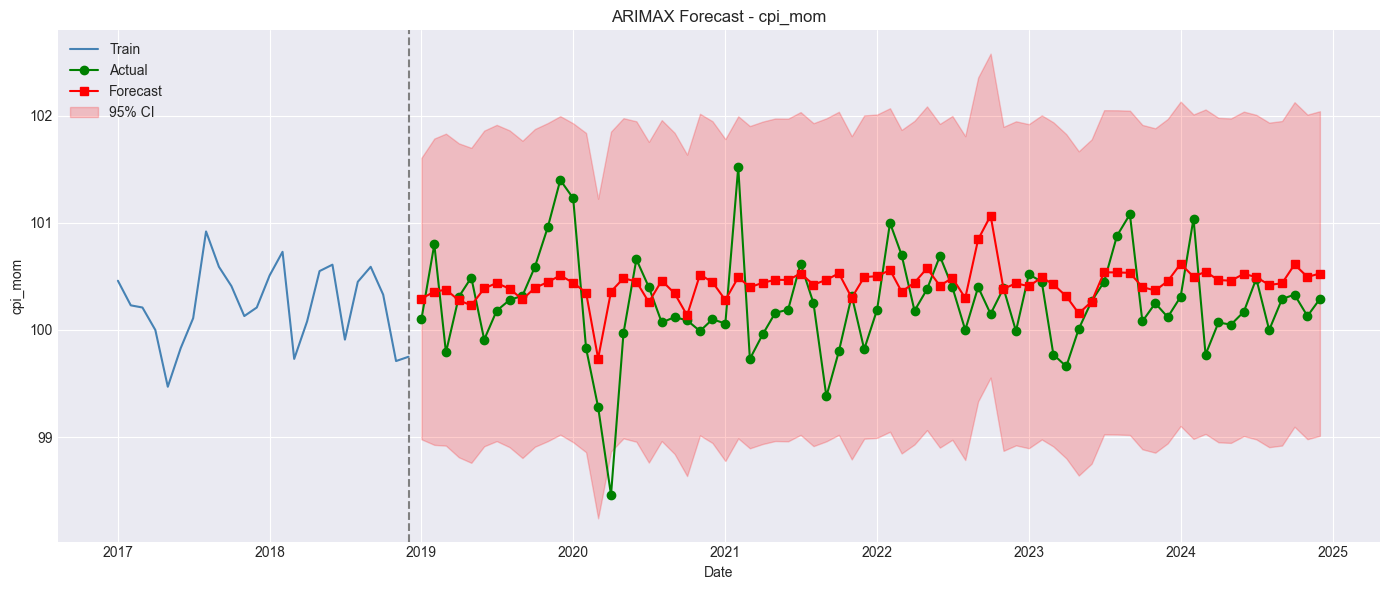

In [91]:
pred_mean = best_eval["pred_mean"]
pred_ci = best_eval["pred_ci"]

plt.figure(figsize=(14, 6))
plt.plot(y_train.index[-24:], y_train.iloc[-24:], label="Train", color="steelblue")
plt.plot(y_test.index, y_test.values, label="Actual", color="green", marker="o")
plt.plot(pred_mean.index, pred_mean.values, label="Forecast", color="red", marker="s")
plt.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color="red", alpha=0.2, label="95% CI")
plt.axvline(y_train.index[-1], color="gray", linestyle="--")
plt.title(f"ARIMAX Forecast - {target_var}")
plt.xlabel("Date")
plt.ylabel(target_var)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "test_forecast.png"), dpi=150)
plt.show()

In [92]:
# in ra số liệu cpi_mom
print("CPI MoM actual:")
print(y_test.round(4).to_string())
# thực tế
print("\nCPI MoM forecast:")
print(pred_mean.round(4).to_string())

CPI MoM actual:
date
2019-01-01    100.10
2019-02-01    100.80
2019-03-01     99.79
2019-04-01    100.31
2019-05-01    100.49
2019-06-01     99.91
2019-07-01    100.18
2019-08-01    100.28
2019-09-01    100.32
2019-10-01    100.59
2019-11-01    100.96
2019-12-01    101.40
2020-01-01    101.23
2020-02-01     99.83
2020-03-01     99.28
2020-04-01     98.46
2020-05-01     99.97
2020-06-01    100.66
2020-07-01    100.40
2020-08-01    100.07
2020-09-01    100.12
2020-10-01    100.09
2020-11-01     99.99
2020-12-01    100.10
2021-01-01    100.06
2021-02-01    101.52
2021-03-01     99.73
2021-04-01     99.96
2021-05-01    100.16
2021-06-01    100.19
2021-07-01    100.62
2021-08-01    100.25
2021-09-01     99.38
2021-10-01     99.80
2021-11-01    100.32
2021-12-01     99.82
2022-01-01    100.19
2022-02-01    101.00
2022-03-01    100.70
2022-04-01    100.18
2022-05-01    100.38
2022-06-01    100.69
2022-07-01    100.40
2022-08-01    100.00
2022-09-01    100.40
2022-10-01    100.15
2022-11-01   

## 13. Kiểm định phần dư

Ljung-Box:
     lb_stat  lb_pvalue
5   3.562490   0.613954
10  7.772815   0.651017
Jarque-Bera p-value: 0.0
ARCH p-value: 0.002331


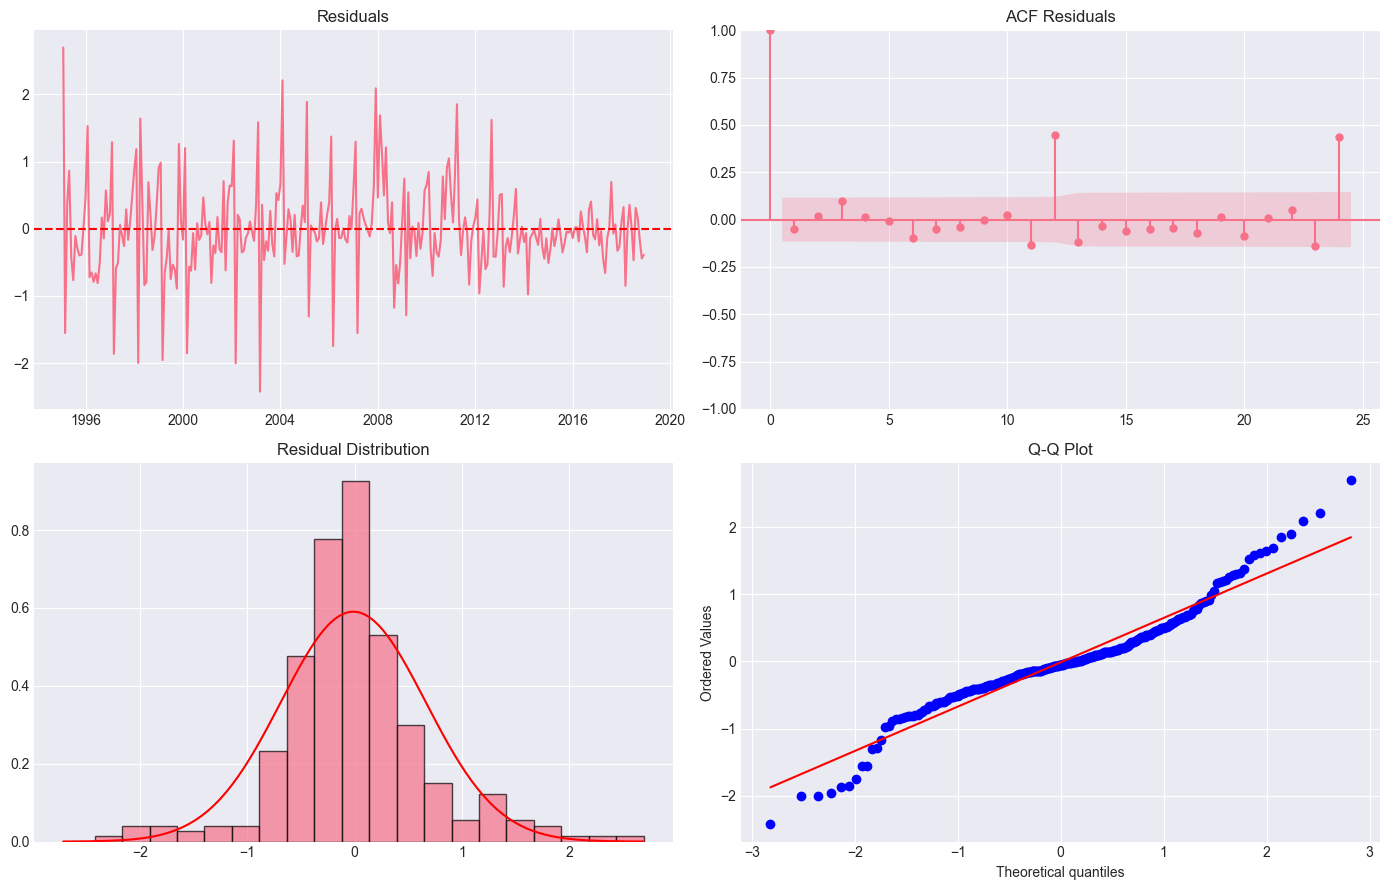

In [93]:
resid = best_model.resid.dropna()

ljung = acorr_ljungbox(resid, lags=[5, 10], return_df=True)
jb_stat, jb_p = jarque_bera(resid)

try:
    arch_stat, arch_p, _, _ = het_arch(resid, nlags=5)
except Exception:
    arch_stat, arch_p = np.nan, np.nan

print("Ljung-Box:")
print(ljung)
print("Jarque-Bera p-value:", round(jb_p, 6))
print("ARCH p-value:", round(arch_p, 6))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(resid.index, resid.values)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals")

plot_acf(resid, lags=min(24, len(resid)//2), ax=axes[0, 1])
axes[0, 1].set_title("ACF Residuals")

axes[1, 0].hist(resid.values, bins=20, density=True, alpha=0.7, edgecolor="black")
mu, sigma = np.mean(resid), np.std(resid)
if sigma > 0:
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    axes[1, 0].plot(x, stats.norm.pdf(x, mu, sigma), color="red")
axes[1, 0].set_title("Residual Distribution")

stats.probplot(resid.values, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "residual_diagnostics.png"), dpi=150)
plt.show()

## 14. Dự báo tương lai nếu mô hình đạt

In [94]:
performance_good = (best_row["Model_vs_RW"] < 1) or (best_row["R2"] > 0)
residual_ok = ljung["lb_pvalue"].min() > 0.05

print("Mô hình đạt benchmark:", performance_good)
print("Phần dư đạt Ljung-Box:", residual_ok)

future_steps = 12

if performance_good:
    order = best_row["order"]
    y_full = df_model[target_var]

    if len(exog_vars) == 0:
        exog_full = None
        exog_future = None
    else:
        exog_full = df_model[exog_vars]
        future_index = pd.date_range(start=df_model.index[-1], periods=future_steps + 1, freq="MS")[1:]
        exog_future = pd.DataFrame(index=future_index)
        for col in exog_vars:
            if col == "month":
                exog_future[col] = future_index.month
            elif col == "quarter":
                exog_future[col] = future_index.quarter
            elif col.startswith("shock_"):
                exog_future[col] = 0
            else:
                exog_future[col] = exog_full[col].iloc[-1]

    final_model = ARIMA(y_full, exog=exog_full, order=order)
    final_res = final_model.fit()
    future = final_res.get_forecast(steps=future_steps, exog=exog_future)
    future_mean = future.predicted_mean
    future_ci = future.conf_int(alpha=0.05)

    plt.figure(figsize=(14, 6))
    plt.plot(y_full.index[-36:], y_full.iloc[-36:], label="Historical", color="steelblue")
    plt.plot(future_mean.index, future_mean.values, label="Forecast", color="red", marker="s")
    plt.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1], color="red", alpha=0.2, label="95% CI")
    plt.axvline(y_full.index[-1], color="gray", linestyle="--")
    plt.title(f"Future Forecast - {target_var}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "future_forecast.png"), dpi=150)
    plt.show()

    future_df = pd.DataFrame({"forecast": future_mean, "lower_95": future_ci.iloc[:, 0], "upper_95": future_ci.iloc[:, 1]})
    future_df.to_csv(os.path.join(OUTPUT_DIR, "future_forecast.csv"))
    print(future_df.to_string())
else:
    print("Không vẽ dự báo tương lai vì mô hình chưa vượt benchmark.")

Mô hình đạt benchmark: True
Phần dư đạt Ljung-Box: True


ValueError: cannot reindex on an axis with duplicate labels

## 15. Tóm tắt

In [ ]:
print("Target:", target_var)
print("Best model:", best_key)
print("RMSE:", round(best_row["RMSE"], 6))
print("MAE:", round(best_row["MAE"], 6))
print("R2:", round(best_row["R2"], 4))
print("Model_vs_RW:", round(best_row["Model_vs_RW"], 4))
print("Model_vs_Mean:", round(best_row["Model_vs_Mean"], 4))
print("Output:", OUTPUT_DIR)

Target: cpi_mom_inflation
Best model: ARIMAX_(2, 0, 1)
RMSE: 0.519372
MAE: 0.408251
R2: -0.2239
Model_vs_RW: 0.7564
Model_vs_Mean: 0.9672
Output: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step4_arimax
